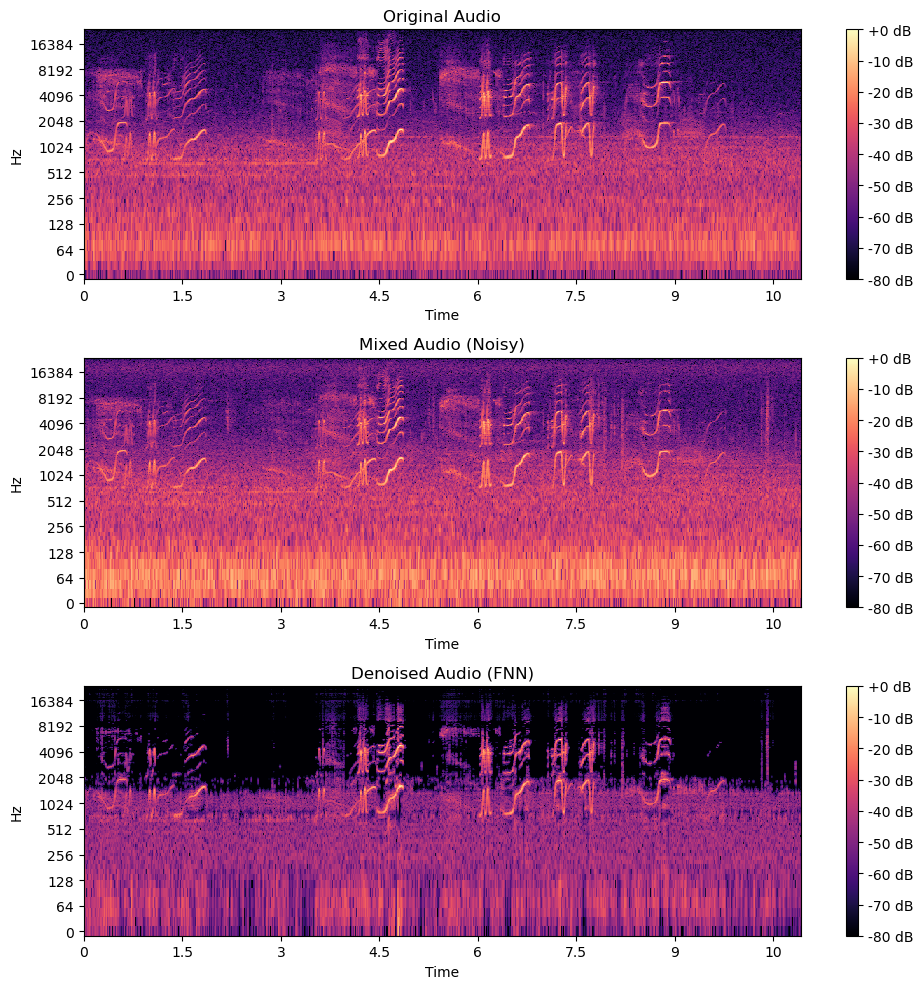

In [7]:
import os
import sys
sys.path.append(os.path.expanduser('~') + r"\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages")
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# File paths
audio_files = [
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Original_bird_sounds\8109__klankbeeld__birds\185364__klankbeeld__northern-lapwing-vanellus-vanellus.wav",
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Mixed_Audio\185364__klankbeeld__northern-lapwing-vanellus-vanellus_546490__klankbeeld__calm-forest-nov-oisterwijk-nl-01-201127_0208.wav",
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Denoised_audio_fnn_7_epochs\denoised_185364__klankbeeld__northern-lapwing-vanellus-vanellus_546490__klankbeeld__calm-forest-nov-oisterwijk-nl-01-201127_0208.wav"
]

titles = ["Original Audio", "Mixed Audio (Noisy)", "Denoised Audio (FNN)"]

# Plot spectrograms
plt.figure(figsize=(10, 10))
for i, file in enumerate(audio_files):
    # Load audio
    y, sr = librosa.load(file, sr=None)
    
    # Compute spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    
    # Plot
    plt.subplot(3, 1, i+1)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(titles[i])
    
plt.tight_layout()
plt.show()


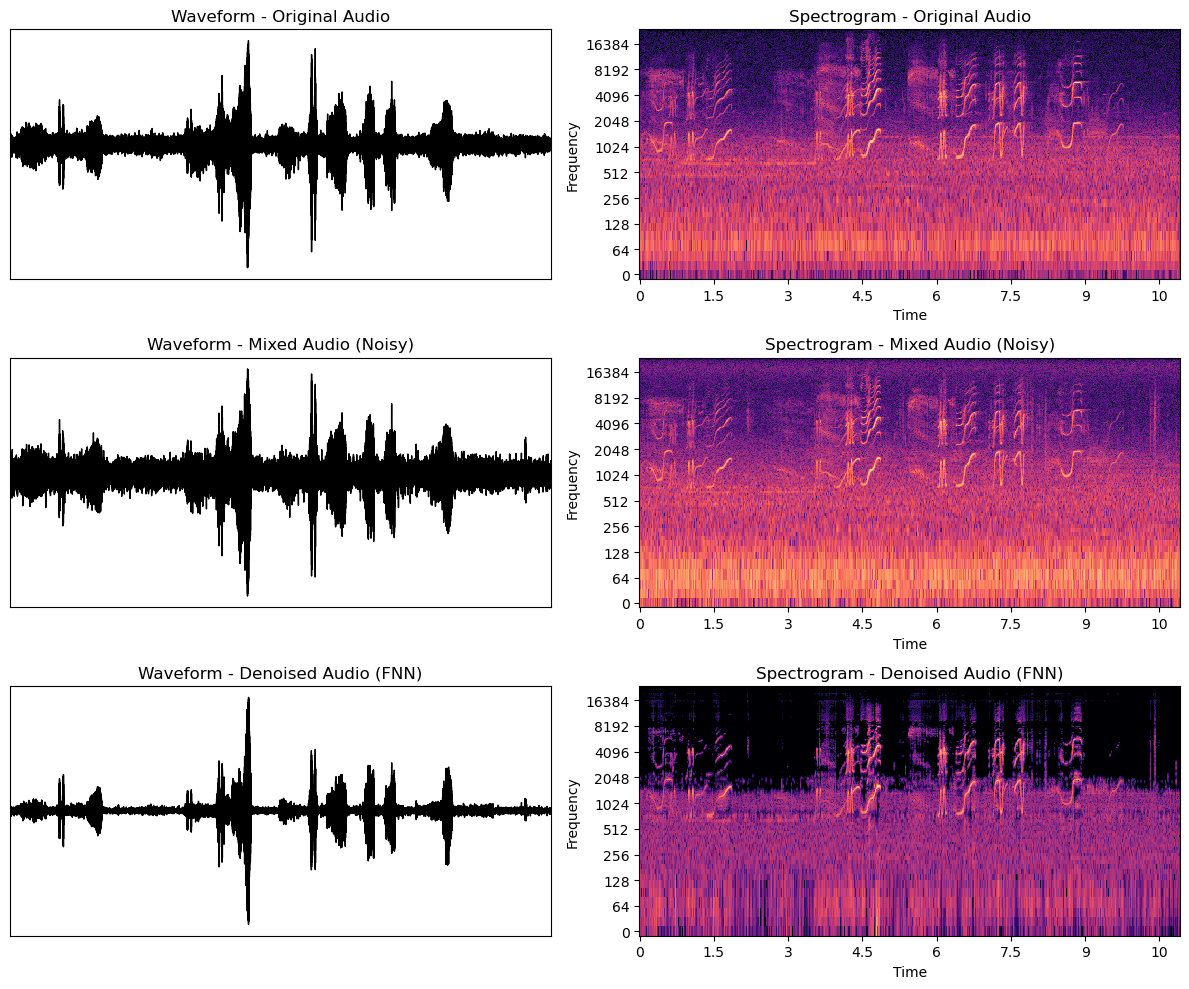

In [11]:
import os
import sys
sys.path.append(os.path.expanduser('~') + r"\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages")
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# File paths
audio_files = [
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Original_bird_sounds\8109__klankbeeld__birds\185364__klankbeeld__northern-lapwing-vanellus-vanellus.wav",
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Mixed_Audio\185364__klankbeeld__northern-lapwing-vanellus-vanellus_546490__klankbeeld__calm-forest-nov-oisterwijk-nl-01-201127_0208.wav",
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Denoised_audio_fnn_7_epochs\denoised_185364__klankbeeld__northern-lapwing-vanellus-vanellus_546490__klankbeeld__calm-forest-nov-oisterwijk-nl-01-201127_0208.wav"
]

titles = ["Original Audio", "Mixed Audio (Noisy)", "Denoised Audio (FNN)"]

# Plot waveforms and spectrograms
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for i, file in enumerate(audio_files):
    # Load audio
    y, sr = librosa.load(file, sr=None)
    
    # Compute spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

    # Plot waveform
    axes[i, 0].plot(y, color='black', linewidth=1)
    axes[i, 0].set_title(f"Waveform - {titles[i]}")
    axes[i, 0].set_xlim(0, len(y))
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # Plot spectrogram
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=axes[i, 1])
    axes[i, 1].set_title(f"Spectrogram - {titles[i]}")
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [3]:
import os
import sys
sys.path.append(os.path.expanduser('~') + r"\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages")
import librosa
import numpy as np

# File paths
audio_files = [
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Original_bird_sounds\8109__klankbeeld__birds\185364__klankbeeld__northern-lapwing-vanellus-vanellus.wav",
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Mixed_Audio\185364__klankbeeld__northern-lapwing-vanellus-vanellus_546490__klankbeeld__calm-forest-nov-oisterwijk-nl-01-201127_0208.wav",
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Denoised_audio_fnn_7_epochs\denoised_185364__klankbeeld__northern-lapwing-vanellus-vanellus_546490__klankbeeld__calm-forest-nov-oisterwijk-nl-01-201127_0208.wav"
]

# Load audio files
audio_data = []
sampling_rates = []

for file in audio_files:
    y, sr = librosa.load(file, sr=None)
    audio_data.append(y)
    sampling_rates.append(sr)

# Ensure all signals have the same length by padding/trimming
min_length = min(len(audio_data[0]), len(audio_data[1]), len(audio_data[2]))

audio_data = [y[:min_length] for y in audio_data]  # Trim all to the same length

# Compute Mean Squared Error (MSE) Loss
def mse_loss(reference, target):
    return np.mean((reference - target) ** 2)

loss_noisy = mse_loss(audio_data[0], audio_data[1])  # Original vs Noisy
loss_denoised = mse_loss(audio_data[0], audio_data[2])  # Original vs Denoised

# Print loss values
print(f"MSE Loss (Original vs Noisy): {loss_noisy:.6f}")
print(f"MSE Loss (Original vs Denoised): {loss_denoised:.6f}")
print(f"Loss Improvement: {loss_noisy - loss_denoised:.6f}")


MSE Loss (Original vs Noisy): 0.001242
MSE Loss (Original vs Denoised): 0.000323
Loss Improvement: 0.000919


In [13]:
import os
import sys
sys.path.append(os.path.expanduser('~') + r"\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages")
import librosa
import numpy as np

# File paths
audio_files = [
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Test_Audio\test_noisy_bird_4.wav", 
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Denoised_Test_Output\denoised_test_4.wav"

    
]

# Load audio files
audio_data = []
sampling_rates = []

for file in audio_files:
    y, sr = librosa.load(file, sr=None)
    audio_data.append(y)
    sampling_rates.append(sr)

# Ensure all signals have the same length by padding/trimming
min_length = min(len(audio_data[0]), len(audio_data[1]))

audio_data = [y[:min_length] for y in audio_data]  # Trim all to the same length

# Compute Mean Squared Error (MSE) Loss
def mse_loss(reference, target):
    return np.mean((reference - target) ** 2)

loss_predicted = mse_loss(audio_data[0], audio_data[1])  # Original vs Predicted

# Print loss values
print(f"MSE Loss (Noisy vs Predicted Denoised): {loss_predicted:.6f}")



MSE Loss (Noisy vs Predicted Denoised): 0.004774


In [21]:
import os
import sys
sys.path.append(os.path.expanduser('~') + r"\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages")
import librosa
import numpy as np

# File paths
audio_files = [
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Test_Audio\test_noisy_bird_4_original.wav", 
    r"C:\Users\benji\Documents\Bird_Project_Code\FNN_Filter\Test_Audio\test_noisy_bird_4.wav"

    
]

# Load audio files
audio_data = []
sampling_rates = []

for file in audio_files:
    y, sr = librosa.load(file, sr=None)
    audio_data.append(y)
    sampling_rates.append(sr)

# Ensure all signals have the same length by padding/trimming
min_length = min(len(audio_data[0]), len(audio_data[1]))

audio_data = [y[:min_length] for y in audio_data]  # Trim all to the same length

# Compute Mean Squared Error (MSE) Loss
def mse_loss(reference, target):
    return np.mean((reference - target) ** 2)

loss_predicted = mse_loss(audio_data[0], audio_data[1])  # Original vs Predicted

# Print loss values
print(f"MSE Loss (Original vs Noisy): {loss_predicted:.6f}")



MSE Loss (Original vs Noisy): 0.000335
